# Oblig 2

- All exercises should be solved by splitting the dataset into 60% training, 20% validation,
and 20% test, using a stratified split so that the class ratio is preserved across
all three sets.

- Use the training set for 5-fold stratified cross-validation, the validation
set for model selection and hyperparameter tuning, and reserve the test set strictly
for final evaluation.

- For each experiment, report the mean and standard deviation
of accuracy (and, where specified, other metrics such as precision, recall, F1, or AUC)
among the folds. Given the class imbalance, accuracy alone is not sufficient; wherever it
is asked for, also report at least one imbalance-aware metric (e.g., balanced accuracy, F1,
or ROC-AUC).

In [1]:
import numpy as np
# import the dataset, and download for further use.
# Run this once to get the data

from ucimlrepo import fetch_ucirepo

def import_data() -> None:
    """
    Gets the dataset, and makes local csv
    """
    # fetch dataset
    adult = fetch_ucirepo(id=2)

    # data (as pandas dataframes)
    X = adult.data.features
    y = adult.data.targets

    X.to_csv("adult_features.csv", index=False)
    y.to_csv("adult_targets.csv", index=False)


In [2]:
# we now have the data locally as csv files
import pandas as pd

# import_data() # gets the dataset,

X = pd.read_csv("adult_features.csv") # features
y = pd.read_csv("adult_targets.csv")  # targets

print(X.describe())

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  48842.000000  4.884200e+04   48842.000000  48842.000000  48842.000000   
mean      38.643585  1.896641e+05      10.078089   1079.067626     87.502314   
std       13.710510  1.056040e+05       2.570973   7452.019058    403.004552   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.175505e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.781445e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.376420e+05      12.000000      0.000000      0.000000   
max       90.000000  1.490400e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    48842.000000  
mean        40.422382  
std         12.391444  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  


In [3]:
from sklearn.model_selection import train_test_split

def train_val_test_split(X, y):
    """
    Create a 60, 20, 20 split for train, test and validation
    :param X: The set containing the features
    :param y: The set containing the targets
    :return: X_train, X_val, X_test, y_train, y_val, y_test
    """
    # First split into training+validation (80%) and test (20%)
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y  # Use stratify for classification
    )

    # Calculate the validation size relative to the train_val set
    # If test is 20%, validation is 20%, then validation is 20 / (100-20) = 20/80 = ~0.25
    val_size_relative = 0.20 / (1.0 - 0.20)

    # Split train_val into final training and validation sets
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val,
        y_train_val,
        test_size=val_size_relative,
        random_state=42,
        stratify=y_train_val  # Use stratify again
    )

    return X_train, X_val, X_test, y_train, y_val, y_test

# https://apxml.com/courses/introduction-to-neural-networks/chapter-2-data-preparation-neural-networks/data-splitting

In [4]:
# The dataset without missing values, split into 60/20/20 splits
X_train, X_val, X_test, y_train, y_val, y_test = train_val_test_split(X, y) # todo: replace with the non-null data

# check sizes
print(f"Original dataset size: {len(X)}")
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

#We now have a training set (60% of total data) which we can use StratifiedKFold on.

Original dataset size: 48842
Training set size: 29304
Validation set size: 9769
Test set size: 9769


## Data preparation

In [5]:
X_train.info()
# from .shape() we expect 48842 non-null values.
# we can see that there are missing values in the dataframe

<class 'pandas.DataFrame'>
Index: 29304 entries, 48092 to 30449
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             29304 non-null  int64
 1   workclass       28746 non-null  str  
 2   fnlwgt          29304 non-null  int64
 3   education       29304 non-null  str  
 4   education-num   29304 non-null  int64
 5   marital-status  29304 non-null  str  
 6   occupation      28745 non-null  str  
 7   relationship    29304 non-null  str  
 8   race            29304 non-null  str  
 9   sex             29304 non-null  str  
 10  capital-gain    29304 non-null  int64
 11  capital-loss    29304 non-null  int64
 12  hours-per-week  29304 non-null  int64
 13  native-country  29149 non-null  str  
dtypes: int64(6), str(8)
memory usage: 3.4 MB


In [6]:
X_train.head(5)
# we can see that missing data is encoded as ?

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
48092,22,Private,535027,Some-college,10,Never-married,Transport-moving,Unmarried,Black,Male,0,0,15,United-States
31972,43,Self-emp-inc,62026,Prof-school,15,Married-civ-spouse,Exec-managerial,Husband,White,Male,99999,0,40,United-States
36415,44,Private,227466,Some-college,10,Married-civ-spouse,Transport-moving,Husband,Black,Male,0,0,40,United-States
36832,32,State-gov,19513,Masters,14,Never-married,Prof-specialty,Not-in-family,Asian-Pac-Islander,Female,0,0,40,Japan
752,58,Self-emp-not-inc,87510,10th,6,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,40,United-States


In [7]:
# Q1.1

def missing_features(X)-> None:
    """
    Identify which features have missing data, and how many

    The spesific dataset used here encodes missing data as "?"
    Chec
    :param X: Feature set
    """
    X[X == '?'] = np.nan # replace ? with Nan, for string columns this is missing data
    print(X.isnull().sum()) # count the amount of missing values

missing_features(X_train)

age                  0
workclass         1633
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1639
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     505
dtype: int64


In [8]:
# Check correlation between missing occupation and workclass
def check_correlation(X, feature_1, feature_2, feature_3) -> None:
    """
    Given that both features have missing values. Checks the correlation between two features in a given dataset.
    :param X: dataset containing feature_1 and feature_2
    :param feature_1: first feature
    :param feature_2: second feature
    :return: None
    """
    X_relevant = X[[feature_1, feature_2, feature_3]]

    X_missing_corr= X_relevant.isnull().corr() # check correlation between missing values

    print(X_missing_corr)
    # the output will be dataframe (2x2)
    # Which tells if the two features are missing together
    # Value close to 1 means that the often are missing together
    # Value close to -1 means that they are mutually exclusive, ie feature_1 is missing and feature_2 exist
    # Close to 0 means no correlation, you can not tell anything about feature_2 given feature_1

check_correlation(X_train, "occupation", "workclass", "native-country")

                occupation  workclass  native-country
occupation        1.000000   0.998060        0.000861
workclass         0.998060   1.000000        0.000981
native-country    0.000861   0.000981        1.000000


From this we can see that the missing values are highly a missing occupation is highly associated with a missing workclass ($0.998 \approx 1 $). We can also see that missing native-country is unrealated to the other missing features.

In [9]:
missing_workclass = X_train['workclass'].isnull()
print(X_train.loc[missing_workclass, 'hours-per-week'].describe())

zero_hours_missing = (X_train.loc[X['workclass'].isnull(), 'hours-per-week'] == 0).sum()
print(f"Missing workclass AND 0 hours: {zero_hours_missing}")

count    1633.000000
mean       31.559094
std        14.974499
min         1.000000
25%        20.000000
50%        35.000000
75%        40.000000
max        99.000000
Name: hours-per-week, dtype: float64
Missing workclass AND 0 hours: 0


In [10]:
missing_workclass = X_train['workclass'].isnull()
print(X_train.loc[~missing_workclass, 'hours-per-week'].describe())

count    27671.000000
mean        40.879260
std         12.095009
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64


Based on [determine imputation](https://stats.stackexchange.com/questions/541337/how-should-i-determine-what-imputation-method-to-use) we assume (cannot conclude MAR vs MNAR form just obsered data) that the missing values are MAR (missing at random). Which means that "the probability the data are missing has something to do with variables". We have seen that the missing occupation correlates with missing workclass, this is one missingness event (skip-logic event). There are also no row with missing workclass that is associated with 0 hours worked, which means that the correspondent is working. This suggests the missingness is better explained by other observed variables.

The missingness in workclass/occupation is explainable* by variables we can observe, thus it has information we can use. This allows us to encode it as a missing catagory.

We should not delete the rows with missing data as this would remove a non-random subset, it linked with occupation and correlated with a lower hrs/week. We decide on creating a missing category, this is because we are working with a categorical features, so mean imputation would not work. And because it is non-random it carries some information.

The risk is if the data is not missing at random (MNAR), if there is some correlation between high earners and missing features. It may use missing as a substitute for high earners. This is a more general problem, pattern as to why something is missing. Using a new catagory increases cardinalty. It can lead to a sparse column (many 0s) when doing onehot encoding.

In [11]:
def replace_missing(X, feature_1, feature_2, feature_3) -> pd.DataFrame:
    """
    Replace missing data in rows with the column features_1-3, with a missing category
    :param X: Dataset
    :param feature_1: feature 1
    :param feature_2: feature 2
    :param feature_3: feature 3
    :return: New dataset with missing category
    """
    X[feature_1] = X[feature_1].fillna('Missing')
    X[feature_2] = X[feature_2].fillna('Missing')
    X[feature_3] = X[feature_3].fillna('Missing')


    return X

X_nonmissing = replace_missing(X_train, "occupation", "workclass", "native-country")

In [12]:
# look at what categories we have for native_country
def check_catagory(X, feature):
    """
    Checks the distribution in a given category
    :param X: dataset
    :param feature: target category
    :return: distribution of values within the category
    """
    counts = X[feature].value_counts(dropna=False)
    proportions = X[feature].value_counts(dropna=False, normalize=True)
    return pd.DataFrame({'count': counts, 'proportion': proportions})

print(check_catagory(X_train, "native-country").head(5)) # check 5 most

                count  proportion
native-country                   
United-States   26309    0.897796
Mexico            596    0.020339
Missing           505    0.017233
Philippines       184    0.006279
Germany           126    0.004300


In [13]:
# check non missing
def check_category_by_missingness(X, y, missing_col, compare_col):
    """
    Compares the distribution of `compare_col` between rows where
    `missing_col` is missing vs. not missing.
    :param X dataset
    :param y dataset containing target
    :param missing_col: column whose missingness defines the two groups
    :param compare_col: column whose distribution we compare across groups
    :return: DataFrame of proportions, one column per group
    """
    X_y = pd.concat([X, y], axis=1)
    is_missing = X_y[missing_col].isna()
    dist_missing = X_y.loc[is_missing, compare_col].value_counts(normalize=True)
    dist_present = X_y.loc[~is_missing, compare_col].value_counts(normalize=True)
    return pd.DataFrame({
        f'{missing_col}_missing': dist_missing,
        f'{missing_col}_present': dist_present
    })
check_category_by_missingness(X_train, y_train,'native-country', 'race')
check_category_by_missingness(X_train, y_train,'native-country', 'income')  # check MNAR

,native-country_missing,native-country_present
income,,
<=50K,NaN,0.506108
<=50K.,NaN,0.254607
>50K,NaN,0.160524
>50K.,NaN,0.078761


We are missing 505 native-country entries, and USA is the dominant value. Thus it is reasonable to encode missing country as USA. And there little indication that its MNAR (slighlty favors higher income, by 1%\~), but it could also be noise. Based on USA being the majority the poll was likely conducted in the US (which is [true](https://www.cs.toronto.edu/~delve/data/adult/adultDetail.html ). Therefore a likely reason is that the participent didnt want to give out contry of origin. This would make it MNAR, since the missingness would be tied to the value itself. From this we conclude that use of missing category should be fine.

In [14]:
# Q1.2
def outliers_IQR(X, feature_list, verbose=True):
    """
    Detect outliers in numerical features using the IQR method.

    :param X: DataFrame containing the features
    :param feature_list: list of numerical column names to check
    :return: dict mapping feature name -> boolean mask (True = outlier)
    """
    outlier_masks = {}

    for col in feature_list:
        Q1 = X[col].quantile(0.25) # define Q1
        Q3 = X[col].quantile(0.75) # define Q3
        IQR = Q3 - Q1

        # create the bounds
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        mask = (X[col] < lower_bound) | (X[col] > upper_bound) # create a mask to check if a row is above or below the bound
        outlier_masks[col] = mask # apply the mask

        if verbose:
            print(f"{col}: outliers={mask.sum()} ({mask.mean()*100:.2f}%)")

    return outlier_masks

int_features = ["age", "fnlwgt", "education-num", "capital-gain", "capital-loss", "hours-per-week"]
outlier_masks = outliers_IQR(X_train, int_features)


age: outliers=135 (0.46%)
fnlwgt: outliers=862 (2.94%)
education-num: outliers=1082 (3.69%)
capital-gain: outliers=2414 (8.24%)
capital-loss: outliers=1361 (4.64%)
hours-per-week: outliers=8152 (27.82%)


In [15]:
def outliers_zscore(X, feature_list, threshold=3, verbose=True):
    """
    Detect outliers in numerical features using the Z-score method.

    :param X: DataFrame containing the features
    :param feature_list: list of numerical column names to check
    :param threshold: absolute z-score above which a point is considered an outlier
    :return: dict mapping feature name -> boolean mask (True = outlier)
    """
    outlier_masks = {}

    for col in feature_list:
        mean = X[col].mean()   # define mean
        std = X[col].std()     # define standard deviation

        # compute the z-scores
        z_scores = (X[col] - mean) / std

        mask = z_scores.abs() > threshold  # create a mask to check if a row exceeds the threshold
        outlier_masks[col] = mask          # apply the mask

        if verbose:
            print(f"{col}: outliers={mask.sum()} ({mask.mean()*100:.2f}%)")

    return outlier_masks

outlier_masks = outliers_zscore(X_train, int_features)

age: outliers=116 (0.40%)
fnlwgt: outliers=314 (1.07%)
education-num: outliers=211 (0.72%)
capital-gain: outliers=202 (0.69%)
capital-loss: outliers=1320 (4.50%)
hours-per-week: outliers=372 (1.27%)


Tree-based models are robust to outliers as they split on threshold (feature > threshold). How much above the threshold does not matter. Keeping the outliers works fine for tree based models.

SVMs work on distances between points (in a given norm). $$, the kernels are senstive to scale and spread of features. Thus we should cap the features for use with SVMs.

We should cap since the SVMs work poorly with outliers. We dont remove since we lose sample size, which both models respond poorly too.

In [16]:
# Q1.3
def get_cardinality(X, categorical_cols):
    """
    Reports number of unique categories and size of the largest/smallest
    categories for each categorical feature.
    """
    rows = []
    for col in categorical_cols:
        counts = X[col].value_counts(dropna=False)
        rows.append({
            'feature': col,
            'n_unique': X[col].nunique(dropna=False),
            'top_category': counts.index[0],
        })
    return pd.DataFrame(rows).sort_values('n_unique', ascending=False)

categorical_cols = X_train.columns.tolist()
report = get_cardinality(X_train, categorical_cols)
print(report)

           feature  n_unique        top_category
2           fnlwgt     20102              120277
10    capital-gain       115                   0
12  hours-per-week        95                  40
11    capital-loss        94                   0
0              age        72                  36
13  native-country        42       United-States
3        education        16             HS-grad
4    education-num        16                   9
6       occupation        15      Prof-specialty
1        workclass         9             Private
5   marital-status         7  Married-civ-spouse
7     relationship         6             Husband
8             race         5               White
9              sex         2                Male


In [17]:
# purpose bucketing rare ones
def bucket_rare_categories(X_train, X_test, col, threshold=0.01): # threshold 0.01 as we need 50~ samples for a model/encoder to estimate anything note worthy.
    """
    Buckets categories with frequency below `threshold` (computed on
    X_train only) into 'Other'. Applies the same mapping to X_test to
    avoid leakage / train-test inconsistency.
    """
    freq = X_train[col].value_counts(normalize=True, dropna=False)
    keep = freq[freq >= threshold].index

    X_train_out = X_train.copy()
    X_test_out = X_test.copy()
    X_train_out[col] = X_train_out[col].where(X_train_out[col].isin(keep), 'Other')
    X_test_out[col] = X_test_out[col].where(X_test_out[col].isin(keep), 'Other')
    return X_train_out, X_test_out

def bucket_rare_categories_multi(X_train, X_test, cols, threshold=0.01):
    """
    Applies bucket_rare_categories to each column in `cols` independently.
    """
    X_train_out = X_train.copy()
    X_test_out = X_test.copy()
    for col in cols:
        X_train_out, X_test_out = bucket_rare_categories(
            X_train_out, X_test_out, col, threshold=threshold
        )
    return X_train_out, X_test_out # fit on train, transform on both

rare_X_train, rare_X_test = bucket_rare_categories_multi(X_train, X_test, categorical_cols, threshold=0.01)

In [18]:
print("Before:", get_cardinality(X_train, categorical_cols))
print("After:", get_cardinality(rare_X_train, categorical_cols))
# missing education, this is fine as edu-num is more appropriate

Before:            feature  n_unique        top_category
2           fnlwgt     20102              120277
10    capital-gain       115                   0
12  hours-per-week        95                  40
11    capital-loss        94                   0
0              age        72                  36
13  native-country        42       United-States
3        education        16             HS-grad
4    education-num        16                   9
6       occupation        15      Prof-specialty
1        workclass         9             Private
5   marital-status         7  Married-civ-spouse
7     relationship         6             Husband
8             race         5               White
9              sex         2                Male
After:            feature  n_unique        top_category
0              age        44               Other
3        education        15             HS-grad
4    education-num        15                   9
6       occupation        14      Prof-specialty
12  h

We use rare category bucketing to reduce cardinality of the categorical features. We use the threshold of 0.01 as the amount of samples for each label need to be usefull is around 50. Here 0.1 * 26000 = 260, which is enough to be useful, some of the smaller ones are filter out.

In [19]:
# Q1.4
from sklearn.preprocessing import OneHotEncoder

onehot_cols = ['workclass', 'occupation', 'marital-status', 'relationship', 'race', 'native-country']
binary_cols = ['sex']

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='if_binary')
encoder.fit(rare_X_train[onehot_cols])  # fit on TRAIN only (bucketed version)

X_train_encoded = pd.DataFrame(
    encoder.transform(rare_X_train[onehot_cols]),
    columns=encoder.get_feature_names_out(onehot_cols),
    index=rare_X_train.index
)
X_test_encoded = pd.DataFrame(
    encoder.transform(rare_X_test[onehot_cols]),
    columns=encoder.get_feature_names_out(onehot_cols),
    index=rare_X_test.index
)

raw_dims = sum(X_train[col].nunique() for col in onehot_cols)

bucketed_dims = sum(rare_X_train[col].nunique() for col in onehot_cols)

print(f"Dimensions without bucketing: {raw_dims}")
print(f"Dimensions with bucketing: {bucketed_dims}")

Dimensions without bucketing: 84
Dimensions with bucketing: 43


We use binary encoding on sex as it has cardinality = 2 (M/F). On the rest we use one-hot encoding, because it works well for nominal (no order), unordered labels. This is because avoid creating false ordinal relationships. The main issue is that it creates a new column per unique category. It scales linearly with cardinality, to avoid this we reduce the cardiality. This was done with rare-bucketing, where if the dataset contained less than 250~ samples of a given label it would drop the label. This reduces the cardinality, and thus reduces the number of new columns (of which many maybe sparse).

In [20]:
# Q1.5
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

def cramers_v(x, y):
    """
    Cramér's V for two categorical variables.
    """
    confusion = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    r, k = confusion.shape

    phi2 = chi2 / n
    # bias correction (Bergsma 2013)
    phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))

    rcorr = r - ((r - 1)**2) / (n - 1)
    kcorr = k - ((k - 1)**2) / (n - 1)

    return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1))) if min((kcorr - 1),(rcorr - 1)) > 0 else 0

def correlation_ratio(categories, values):
    """
    Eta (correlation ratio) for a categorical vs numeric variable.
    """
    categories = pd.Series(categories).reset_index(drop=True)
    values = pd.Series(values).reset_index(drop=True)

    cat_means = values.groupby(categories).mean()
    cat_counts = values.groupby(categories).count()

    overall_mean = values.mean()

    ss_between = (cat_counts * (cat_means - overall_mean)**2).sum()
    ss_total = ((values - overall_mean)**2).sum()
    return np.sqrt(ss_between / ss_total) if ss_total > 0 else 0

def mixed_correlation_matrix(X, numeric_cols, categorical_cols):
    cols = numeric_cols + categorical_cols
    n = len(cols)
    mat = pd.DataFrame(np.zeros((n, n)), index=cols, columns=cols)

    for i, c1 in enumerate(cols):
        for j, c2 in enumerate(cols):
            if i == j:
                mat.loc[c1, c2] = 1.0
            elif c1 in numeric_cols and c2 in numeric_cols:
                mat.loc[c1, c2] = X[c1].corr(X[c2])  # Pearson
            elif c1 in categorical_cols and c2 in categorical_cols:
                mat.loc[c1, c2] = cramers_v(X[c1], X[c2])
            else:
                num_col = c1 if c1 in numeric_cols else c2
                cat_col = c2 if c1 in numeric_cols else c1
                mat.loc[c1, c2] = correlation_ratio(X[cat_col], X[num_col])
    return mat

numeric_cols = ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
categorical_cols = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']

corr_matrix = mixed_correlation_matrix(X_train, numeric_cols, categorical_cols)

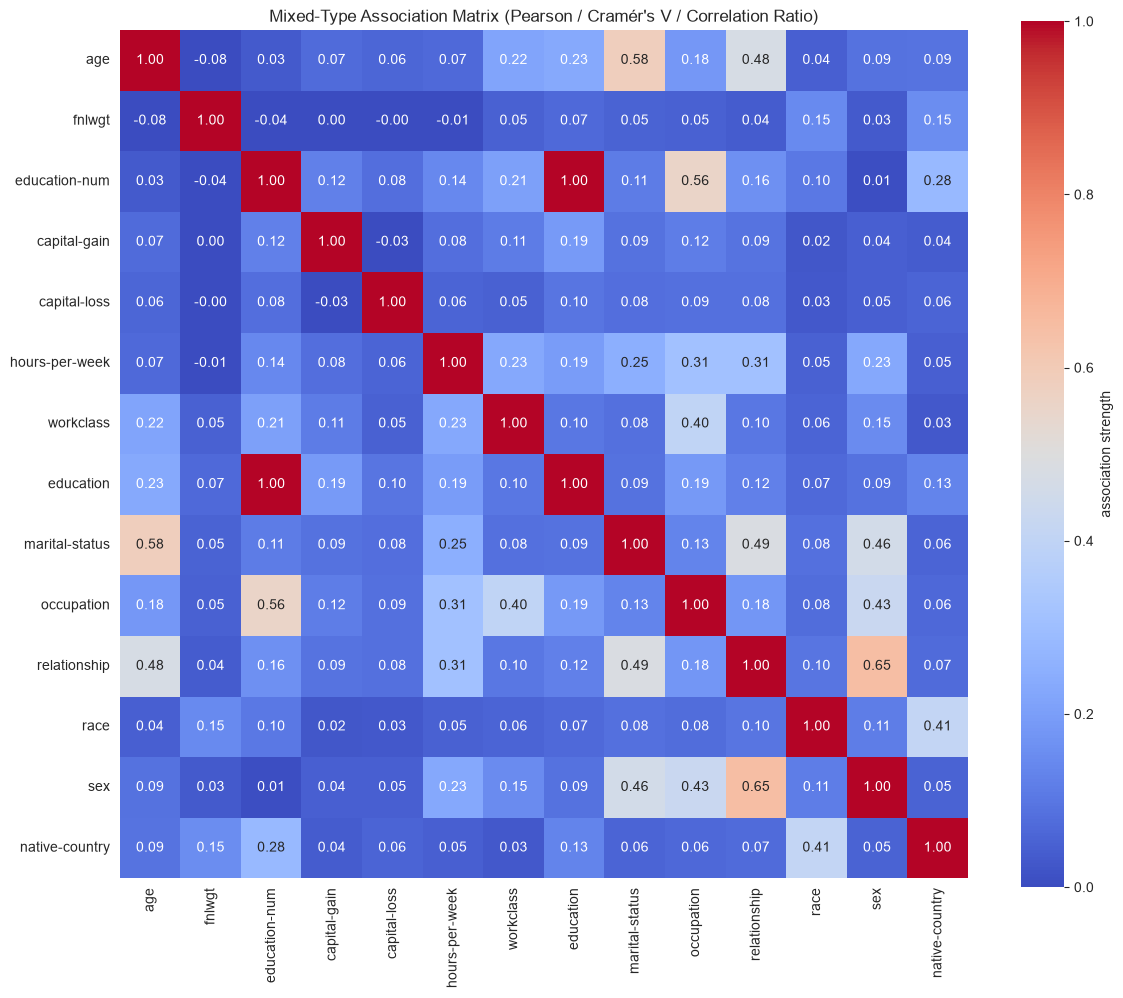

In [21]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix.astype(float), annot=True, fmt='.2f', cmap='coolwarm',
            vmin=0, vmax=1, square=True, cbar_kws={'label': 'association strength'})
plt.title('Mixed-Type Association Matrix (Pearson / Cramér\'s V / Correlation Ratio)')
plt.tight_layout()
plt.show()

Use mix correlation ratio and cramers_v for the correlation matrix. cramers_v is for two categorical and correlation ratio is used for number to category. We identify education and edu-num to be highly correlated, thus they are perfectly multicollinear (1-1 mapping). There are some over 0.5: `age-maritalstatus`, `occupation-edunum` and `sex-relationship`.

For SVM the multicollinearity is a problem because SVM uses a linear combination of weighted features (wx+b). w is found jointly across all features, thus if 2 features have high multicollinearity they carry the same information. We cannot decide which of the features carry the explainability, and get arbitrary coeffitients, sensitive to small changes in the data. Decision tree splits on one feature and one threshold per node that optimize for purity within the node. If two features are highly collinear, it uses the one that creates a better split at a given node. Since they are basically identical, we get the same split for both. Either choice is stable since we get the same portion of the data.

In [22]:
# Q1.6
import pandas as pd
import numpy as np
from scipy.stats import pointbiserialr, chi2_contingency

# target is binary: <=50K = 0, >50K = 1
y_bin = y_train["income"].map({"<=50K": 0, ">50K": 1})

# make sure X and y are aligned
X_train = X_train.reset_index(drop=True)
y_bin = y_bin.reset_index(drop=True)


def cramers_v_scipy(contingency_table):
    """
    Calculate cramers v so we can compare with feature importance
    :param contingency_table: contingency table for features per target
    :return: None
    """
    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.to_numpy().sum()
    r, k = contingency_table.shape
    phi2 = chi2 / n
    return np.sqrt(phi2 / min(k - 1, r - 1)) if min(k - 1, r - 1) > 0 else 0.0

results = []

def point_biserial_corr(X, results):
    """
    Calculate the point-biserial correlation for numerical features to the target
    Ignores rows with missing values, to fix issue with pointbiserialr
    :param X: the dataset
    :param results: the reslut of the correlation
    :return: None
    """
    numeric_cols = X.select_dtypes(include=["number"]).columns.tolist()

    for col in numeric_cols:
        x = X[col].copy()

        # Keep only rows where both feature and target are valid
        mask = x.notna() & y_bin.notna()

        x_valid = x[mask]
        y_valid = y_bin[mask]

        # Skip constant features
        if x_valid.nunique() <= 1:
            continue

        corr, p = pointbiserialr(x_valid, y_valid)

        results.append({
            "feature": col,
            "type": "numeric",
            "statistic": corr,
            "p_value": p,
            "effect_size": abs(corr)
        })

def chi_square(X, results):
    """
    Run the chi-square test for categorical features to the target
    :param X:
    :param results:
    :return:
    """
    categorical_cols = X.select_dtypes(exclude=["number"]).columns.tolist()

    for col in categorical_cols:
        x = X[col].copy().fillna("Missing")
        ct = pd.crosstab(x, y_bin)
        chi2, p, dof, expected = chi2_contingency(ct)
        eff = cramers_v_scipy(ct)
        results.append({
            "feature": col,
            "type": "categorical",
            "statistic": chi2,
            "p_value": p,
            "effect_size": eff
        })


point_biserial_corr(X_train, results)
chi_square(X_train, results)

ranked = (
    pd.DataFrame(results)
    .sort_values(
        ["p_value", "effect_size"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)


print("Top 8 features by significance:")
print(ranked.head(8)[
        ["feature", "type", "statistic", "p_value", "effect_size"]
      ]
      .to_string(index=False)
)


Top 8 features by significance:
       feature        type   statistic       p_value  effect_size
  relationship categorical 4035.907920  0.000000e+00     0.454531
marital-status categorical 3922.688169  0.000000e+00     0.448111
     education categorical 2601.895465  0.000000e+00     0.364954
    occupation categorical 2374.991719  0.000000e+00     0.348678
 education-num     numeric    0.332474  0.000000e+00     0.332474
           age     numeric    0.231730 1.914515e-236     0.231730
hours-per-week     numeric    0.226627 5.803413e-226     0.226627
  capital-gain     numeric    0.222032 9.550240e-217     0.222032


The top features have a small p-values, zero or numerically zero, this indicates a strong correlation with the target (income). Since multiple are zero, we use effect_size to rank.

Features with a p-value of below 0.05 are significat, but the features with higher effect_size have higher associations than the ones with lower value. We would assume a similar pattern, as they will be able to split the data when using decision trees.

RAW
                       mean         std    min      max    range   skew
age                 38.644      13.711     17       90       73  0.558
fnlwgt         189,664.135 105,604.025  12285  1490400  1478115  1.439
education-num       10.078       2.571      1       16       15 -0.317
capital-gain     1,079.068   7,452.019      0    99999    99999 11.895
capital-loss        87.502     403.005      0     4356     4356  4.570
hours-per-week      40.422      12.391      1       99       98  0.239 

STANDARDIZED
                  mean   std    min    max  range   skew
age             0.000 1.000 -1.579  3.746  5.324  0.558
fnlwgt         -0.000 1.000 -1.680 12.317 13.997  1.439
education-num  -0.000 1.000 -3.531  2.303  5.834 -0.317
capital-gain    0.000 1.000 -0.145 13.274 13.419 11.895
capital-loss   -0.000 1.000 -0.217 10.592 10.809  4.570
hours-per-week  0.000 1.000 -3.181  4.727  7.909  0.239 



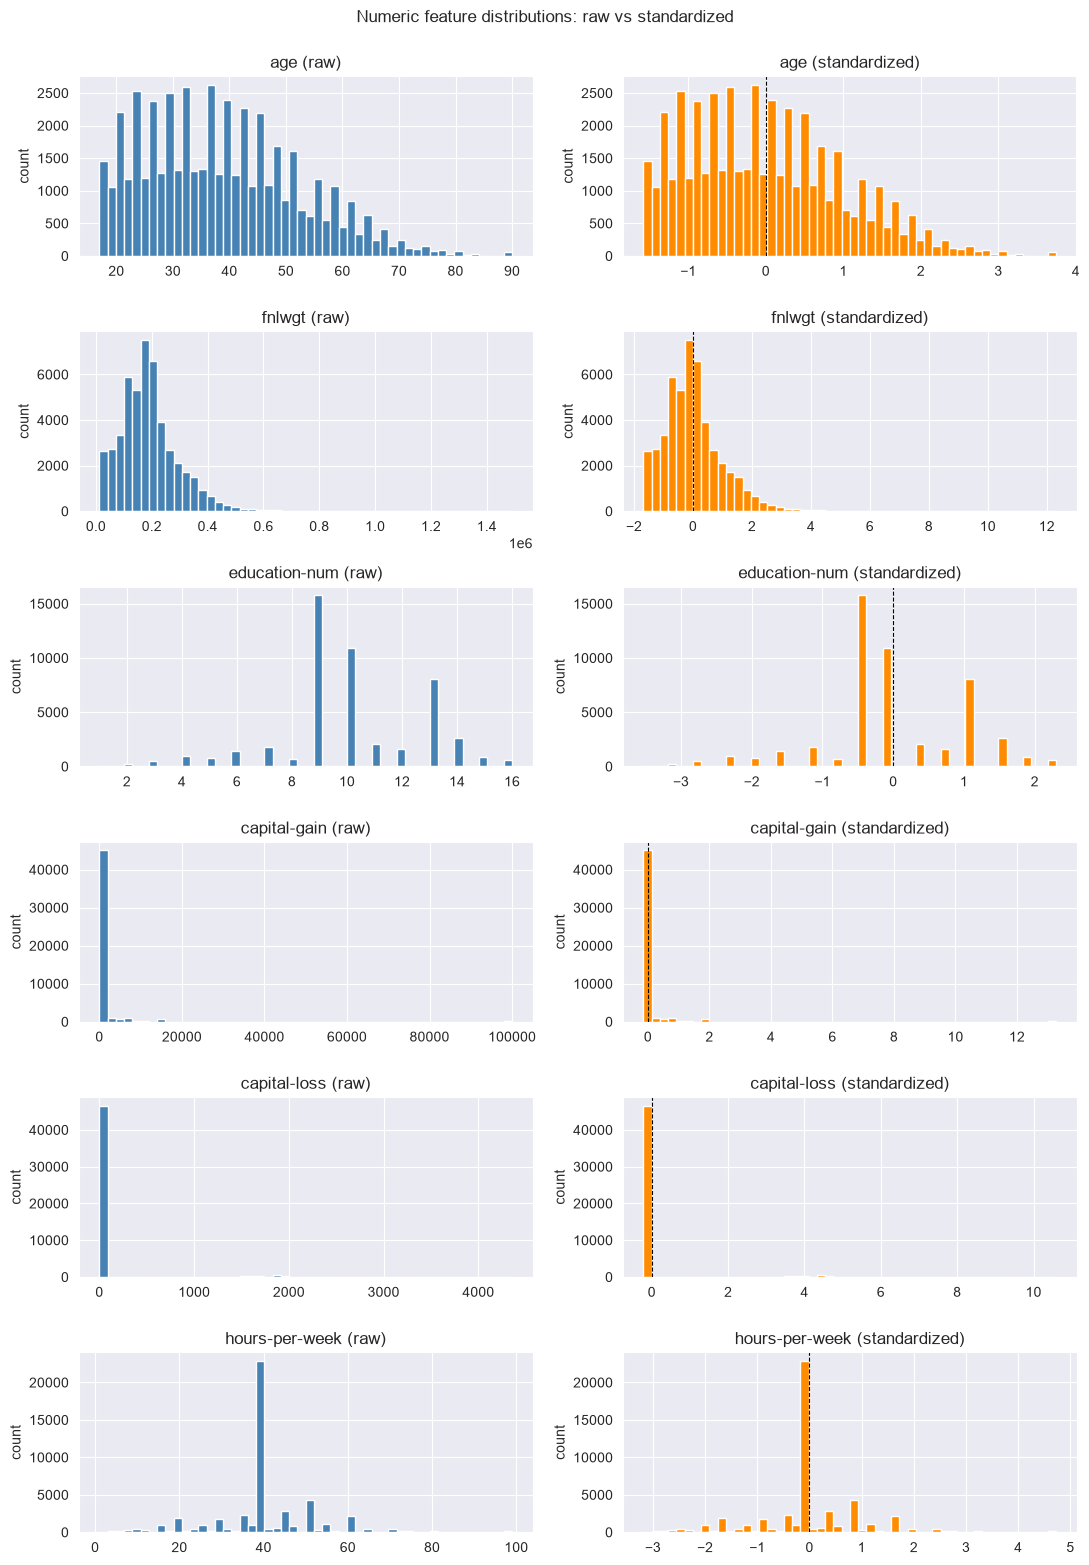

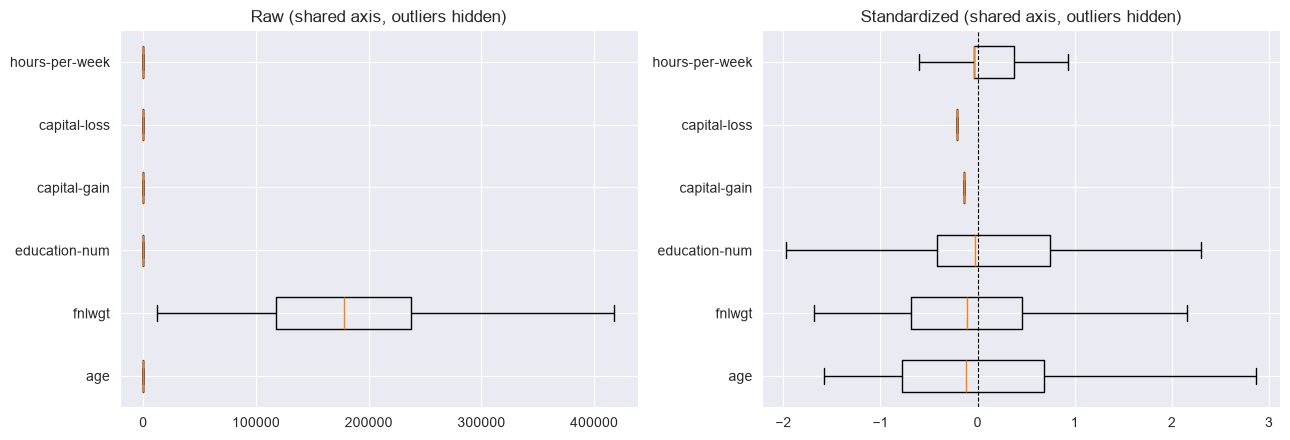

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


def analyze_standardization(X):
    """Standardize numeric features and print summary stats before vs after.

    Returns (X_num, X_std, num_cols).
    NOTE: in the modelling pipeline, fit the scaler on the TRAINING split only.
    """
    num_cols = X.select_dtypes(include="number").columns.tolist()
    X_num = X[num_cols].dropna()

    scaler = StandardScaler()
    X_std = pd.DataFrame(scaler.fit_transform(X_num), columns=num_cols, index=X_num.index)


    def summarize(df):
        return pd.DataFrame({
            "mean": df.mean(), "std": df.std(), "min": df.min(),
            "max": df.max(), "range": df.max() - df.min(), "skew": df.skew(),
        })

    pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
    print("RAW\n", summarize(X_num), "\n")
    print("STANDARDIZED\n", summarize(X_std), "\n")

    return X_num, X_std, num_cols


def plot_standardization(X_num, X_std, num_cols):
    """Plot per-feature histograms and a shared-axis boxplot, raw vs standardized."""
    # Figure 1: per-feature histograms, raw (left) vs standardized (right)
    fig, axes = plt.subplots(len(num_cols), 2, figsize=(11, 2.6 * len(num_cols)))
    for i, col in enumerate(num_cols):
        axes[i, 0].hist(X_num[col], bins=50, color="steelblue", edgecolor="white")
        axes[i, 0].set_title(f"{col} (raw)")
        axes[i, 1].hist(X_std[col], bins=50, color="darkorange", edgecolor="white")
        axes[i, 1].set_title(f"{col} (standardized)")
        axes[i, 1].axvline(0, color="black", lw=0.8, ls="--")
        for ax in axes[i]:
            ax.set_ylabel("count")
    fig.suptitle("Numeric feature distributions: raw vs standardized", y=1.0)
    fig.tight_layout()
    fig.savefig("dist_raw_vs_standardized.png", dpi=150, bbox_inches="tight")

    # Figure 2: all features on one shared axis (shows the scale disparity)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].boxplot([X_num[c] for c in num_cols], orientation="horizontal",
                    tick_labels=num_cols, showfliers=False)
    axes[0].set_title("Raw (shared axis, outliers hidden)")
    axes[1].boxplot([X_std[c] for c in num_cols], orientation="horizontal",
                    tick_labels=num_cols, showfliers=False)
    axes[1].axvline(0, color="black", lw=0.8, ls="--")
    axes[1].set_title("Standardized (shared axis, outliers hidden)")
    fig.tight_layout()
    fig.savefig("boxplot_shared_axis.png", dpi=150, bbox_inches="tight")

    plt.show()

if __name__ == "__main__":
    X = pd.read_csv("adult_features.csv")
    X_num, X_std, num_cols = analyze_standardization(X)
    plot_standardization(X_num, X_std, num_cols)

The features are of different scales (capital vs fnlwgt), standardization makes all features similar in scale. This is important for SVM to work properly, and has no effect on the decision tree. This is because the SVM finds maximum margin boundary using distance between points, with RBF it uses L1 norm. Thus the features in higher scales would dominant. For the tree it makes no difference as it splits on one feature at a time, on a given threshold. The standarization is a linear transform so it changes the threshold but keeps the same distribution when splitting. So for the tree it makes no difference.

We should standardize as we use both SVM and tree based models

In [24]:
# Q1.8
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

import warnings

warnings.filterwarnings(
    "ignore",
    message=r"Found unknown categories in columns \[\d+\] during transform\. These unknown categories will be encoded as the infrequent category\.",
    category=UserWarning,
)

## Full pipeline from raw data

# load the data
X_pipe = pd.read_csv("adult_features.csv", na_values="?", skipinitialspace=True)
y_pipe = (
    pd.read_csv("adult_targets.csv")["income"]
    .str.strip()
    .str.rstrip(".")                      # cleanup: some values are "<=50K." / ">50K."
    .map({"<=50K": 0, ">50K": 1})
)


class ValueBounds(BaseEstimator, TransformerMixin):
    """
    Replaces extreme values with cutoff values learned from the training data.
    """
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        X_arr = np.asarray(X, dtype=float)
        self.n_features_in_ = X_arr.shape[1]
        self.lower_, self.upper_ = np.nanquantile(
            X_arr, [self.lower, self.upper], axis=0
        )
        return self

    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

    def get_feature_names_out(self, input_features=None):
        # clipping doesn't add, drop, or reorder columns
        return np.asarray(input_features, dtype=object)


# 60/20/20 splits (train_val_test_split defined earlier)
X_train_pipe, X_val_pipe, X_test_pipe, y_train_pipe, y_val_pipe, y_test_pipe = train_val_test_split(X_pipe, y_pipe)

# test to see if stratified actually preserves class ratios
print("Train:", y_train_pipe.value_counts(normalize=True).round(3).to_dict())
print("Val:  ", y_val_pipe.value_counts(normalize=True).round(3).to_dict())
print("Test: ", y_test_pipe.value_counts(normalize=True).round(3).to_dict())

# filter by type of column
num_cols = X_pipe.select_dtypes("number").columns.drop("fnlwgt").tolist()
# fnlwgt: final weight. In other words, this is the number of people the census believes the entry represents.
# (https://cseweb.ucsd.edu/classes/sp15/cse190-c/reports/sp15/048.pdf)
# Drop this feature, as it is only the amount of people represented, based on the census survey .
# It represents how the sample was drawn, not an individual.

cat_cols = X_pipe.select_dtypes(exclude="number").columns.tolist()

# split off the binary categorical columns
bin_cols = [c for c in cat_cols if X_pipe[c].nunique(dropna=True) == 2]
cat_cols = [c for c in cat_cols if c not in bin_cols]

# numeric pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("bounds", ValueBounds(lower=0.01, upper=0.99)),
    ("scaler", StandardScaler()),
])

# categorical pipeline: rare levels (<1%) grouped into one "infrequent" column
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
    ("onehot", OneHotEncoder(
        handle_unknown="infrequent_if_exist",
        min_frequency=0.01,
        drop="first",
        sparse_output=False,
    )),
])

# binary pipeline: each binary column becomes a single 0/1 column
binary_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

# combine into a single preprocessor
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_cols),
    ("cat", categorical_pipeline, cat_cols),
    ("bin", binary_pipeline, bin_cols),
])

# fit on train only, then apply the same fitted transform everywhere
X_train_ft = preprocessor.fit_transform(X_train_pipe)
X_val_t = preprocessor.transform(X_val_pipe)
X_test_t = preprocessor.transform(X_test_pipe)
print("Transformed shapes:", X_train_ft.shape, X_val_t.shape, X_test_t.shape)

Train: {0: 0.761, 1: 0.239}
Val:   {0: 0.761, 1: 0.239}
Test:  {0: 0.761, 1: 0.239}
Transformed shapes: (29304, 57) (9769, 57) (9769, 57)


In [25]:
from sklearn import clone

# data leakage means data from validation or test sets influencing fit on the data, before evaluation.
# If this happens it will lead to overfitting, as we are no longer testing on unseen data.
# Here each step in the pipeline learns something about the data, thus every part can leak
# ie. the imputer, scalar, the bounds, the encoder

leaky = clone(preprocessor).fit(X_pipe)   # the wrong way: fit before splitting

j = num_cols.index("capital-loss")
print("fnlwgt 99th pct, train-only:", preprocessor.named_transformers_["num"].named_steps["bounds"].upper_[j])
print("fnlwgt 99th pct, full data: ", leaky.named_transformers_["num"].named_steps["bounds"].upper_[j])

delta = ((
            leaky.named_transformers_["num"].named_steps["bounds"].upper_[j] -
            preprocessor.named_transformers_["num"].named_steps["bounds"].upper_[j]) /
         preprocessor.named_transformers_["num"].named_steps["bounds"].upper_[j])

print(f"capital-loss 99th pct change: {delta:+.2%}")
# We see a small difference in fnlwgt as the dataset is big. But we still see a change in the data.

fnlwgt 99th pct, train-only: 1980.0
fnlwgt 99th pct, full data:  2001.0
capital-loss 99th pct change: +1.06%


# Q1.9
**Comment on the importance of the three-way stratified split with respect to hyperparameter search, class imbalance, and robustness of any learned model.**

A three way stratified split means splitting into training/validation/test.

For hyperparameter search if you fit hyperparameters directly on the test set, you end up overfitting. The model works well for the test-set (since you fit on it), but fails to generalize on new data.

For class imbalance, random sampling can introduce sampling bias, where rare classes are underrepresented. To avoid this stratifying the data, creates a sub-groups (train/test/val) that repressent the class distrobution in the dataset.

For robustness, if a sample is too small or non-representative it creates sampling noise. Stratifying avoid this, ensuring the training happens on representaive sample. Making it hard for it to learn from noise in the data. By testing on unseen data, we will get better measurement of how the model performence on unseen data.


In [26]:
# Q2.1
from sklearn.base import clone
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score

X_train_pipe, X_val_pipe, X_test_pipe, y_train_pipe, y_val_pipe, y_test_pipe = train_val_test_split(X_pipe, y_pipe) # fresh data again

dt_model = Pipeline([
    ("prep", preprocessor), # pipeline from data prep
    ("clf", DecisionTreeClassifier(random_state=42)),  # defaults; seed only for reproducibility
])

# 5-fold Cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(dt_model, X_train_pipe, y_train_pipe, cv=cv,
                        scoring=["accuracy", "balanced_accuracy"])

print(f"CV accuracy:          {scores['test_accuracy'].mean():.4f} +- {scores['test_accuracy'].std():.4f}") # mean +- std
print(f"CV balanced accuracy: {scores['test_balanced_accuracy'].mean():.4f} +- {scores['test_balanced_accuracy'].std():.4f}")

# fit on the full training split, evaluate on validation
dt_model.fit(X_train_pipe, y_train_pipe)
y_val_pred = dt_model.predict(X_val_pipe)
print(f"Validation accuracy:          {accuracy_score(y_val_pipe, y_val_pred):.4f}")
print(f"Validation balanced accuracy: {balanced_accuracy_score(y_val_pipe, y_val_pred):.4f}")

CV accuracy:          0.8151 +- 0.0049
CV balanced accuracy: 0.7429 +- 0.0084
Validation accuracy:          0.8186
Validation balanced accuracy: 0.7482


In [27]:
print("Full dataset:")
print(y_pipe.value_counts().rename({0: "<=50K", 1: ">50K"}))
print(y_pipe.value_counts(normalize=True).rename({0: "<=50K", 1: ">50K"}).round(4))

print(f"\nShare >50K  full: {y_pipe.mean():.4f}")

Full dataset:
income
<=50K    37155
>50K     11687
Name: count, dtype: int64
income
<=50K   0.761
>50K    0.239
Name: proportion, dtype: float64

Share >50K  full: 0.2393


The CV and validation accuracies match closely, meaning that they are reliable. The fold variations are small order 0f 10^-3, that means it not a lucky or unlucky split.

The validation accuracy of 81.86% means that we classify around 82/100 correctly the other falsely for the validation set. The cv accuracy of ~81.51% tells the average accuracy from 5 different fold. The actual amount is 76.1%, so we are around 5% better than just guess above 50k everytime.

The balanced accuracy is the average accuracy within each class. This is better as the data is dominated by <=50k. We get a recall average of ~74%.

In [28]:
feature_names = dt_model.named_steps["prep"].get_feature_names_out()

importances = pd.Series(
    dt_model.named_steps["clf"].feature_importances_,
    index=feature_names,
).sort_values(ascending=False)

print(importances.head(5)) # dropped final wgt, would be 1. otherwise

cat__marital-status_Married-civ-spouse   0.214
num__age                                 0.168
num__education-num                       0.119
num__capital-gain                        0.118
num__hours-per-week                      0.100
dtype: float64


We get features like: `marital-status_Married-civ-spouse`, `age`, `edu-num`, `capital-gain` and `hours-per-week`.

I would say that this makes intuitive sense: marital-status, age and edu-num tend to be higher for people who earn more. (more school, older, tend to be married). They would also have a higher capital gain, and more hours per week (to get paid).

In [29]:
# Q2.3
from sklearn.base import clone
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt


depths = [2, 5, 6, 9, 13, 15]
metrics = ["accuracy", "f1"]
rows = []

for d in depths:
    model = clone(dt_model).set_params(clf__max_depth=d)

    # 5-fold CV on training set: train-fold and held-out-fold scores
    cvr = cross_validate(model, X_train_pipe, y_train_pipe, cv=cv,
                         scoring=metrics, return_train_score=True)

    # fit on full training set, score on the separate validation set
    model.fit(X_train_pipe, y_train_pipe)
    y_val_pred = model.predict(X_val_pipe)

    rows.append({
        "depth": d,
        "train_acc":   cvr["train_accuracy"].mean(),
        "cv_acc":      cvr["test_accuracy"].mean(),
        "cv_acc_std":  cvr["test_accuracy"].std(),
        "train_f1":    cvr["train_f1"].mean(),
        "cv_f1":       cvr["test_f1"].mean(),
        "cv_f1_std":   cvr["test_f1"].std(),
        "val_acc":     accuracy_score(y_val_pipe, y_val_pred),
        "val_f1":      f1_score(y_val_pipe, y_val_pred),
    })

results = pd.DataFrame(rows).set_index("depth")
results["acc_gap"] = results["train_acc"] - results["cv_acc"]
results["f1_gap"]  = results["train_f1"]  - results["cv_f1"]

# readable table: mean ± std for CV columns
table = pd.DataFrame({
    "Train acc":   results["train_acc"].round(4),
    "CV acc":      results.apply(lambda r: f"{r.cv_acc:.4f} ± {r.cv_acc_std:.4f}", axis=1),
    "Val acc":     results["val_acc"].round(4),
    "Train F1":    results["train_f1"].round(4),
    "CV F1":       results.apply(lambda r: f"{r.cv_f1:.4f} ± {r.cv_f1_std:.4f}", axis=1),
    "Val F1":      results["val_f1"].round(4),
    "F1 gap":      results["f1_gap"].round(4),
})
print(table.to_string())

best_depth = results["cv_f1"].idxmax()
print(f"\nBest depth by CV F1: {best_depth} "
      f"(CV F1 = {results.loc[best_depth, 'cv_f1']:.4f} ± {results.loc[best_depth, 'cv_f1_std']:.4f}, "
      f"CV acc = {results.loc[best_depth, 'cv_acc']:.4f} ± {results.loc[best_depth, 'cv_acc_std']:.4f})")

       Train acc           CV acc  Val acc  Train F1            CV F1  Val F1  F1 gap
depth                                                                                
2          0.828  0.8272 ± 0.0045    0.832     0.559  0.5568 ± 0.0240   0.588   0.002
5          0.851  0.8494 ± 0.0049    0.852     0.634  0.6306 ± 0.0154   0.646   0.003
6          0.855  0.8531 ± 0.0054    0.854     0.643  0.6377 ± 0.0205   0.656   0.005
9          0.865  0.8539 ± 0.0057    0.856     0.677  0.6485 ± 0.0114   0.663   0.028
13         0.885  0.8457 ± 0.0041    0.851     0.740  0.6509 ± 0.0167   0.654   0.089
15         0.899  0.8395 ± 0.0042    0.846     0.772  0.6413 ± 0.0180   0.671   0.131

Best depth by CV F1: 13 (CV F1 = 0.6509 ± 0.0167, CV acc = 0.8457 ± 0.0041)


For clf__max_depth=13 we get the best F1 score:CV F1 = 0.6509 ± 0.0167 and CV acc = 0.8457 ± 0.0041.

For depth=2 we have training acc 0.828 and f1 0.599, both are low and validation are similar. The tree is underfitting, we do not have enough depth.

Depth 5-6, better scores, the extra depth reduces the amount of underfitting.

For depth 9 we get better scores again (accuracy 0.865, F1 0.677), with validation (0.856, 0.663). The F1 gap increases meaning we are sliding towards overfitting.

At depth 13-15, we are overfitting F1 gap grows more. Training scores incrase, reaching 0.899 accuracy and 0.772 F1 at depth 15, but validation accuracy decreases to 0.846. CV accuracy also decreases (0.8457 at depth 13, 0.8395 at depth 15), so the extra complexity no longer helps generalisation.

THe best depth to balance over/under fitting and F1 gap (between val and CV) would be around 9.

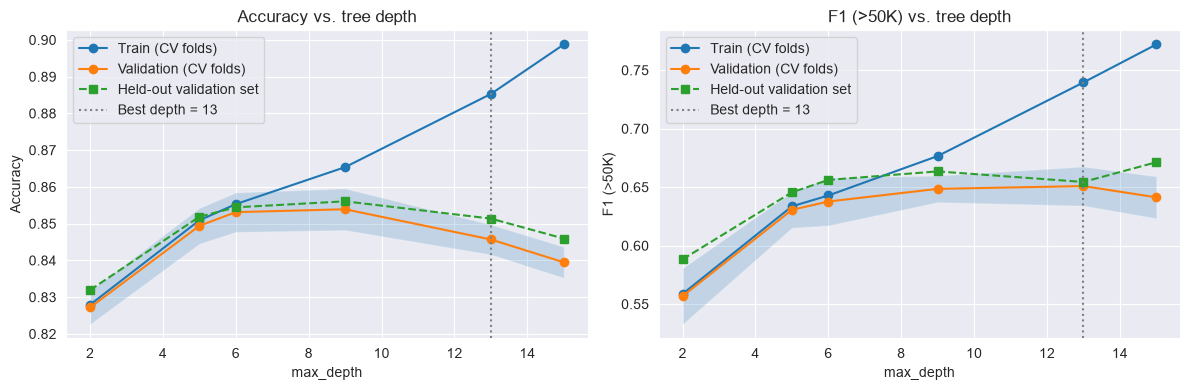

In [30]:
# plot: train vs CV with ±1 std band, plus validation set
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)
for ax, m, label in [(axes[0], "acc", "Accuracy"), (axes[1], "f1", "F1 (>50K)")]:
    ax.plot(results.index, results[f"train_{m}"], "o-", label="Train (CV folds)")
    ax.plot(results.index, results[f"cv_{m}"], "o-", label="Validation (CV folds)")
    ax.fill_between(results.index,
                    results[f"cv_{m}"] - results[f"cv_{m}_std"],
                    results[f"cv_{m}"] + results[f"cv_{m}_std"], alpha=0.2)
    ax.plot(results.index, results[f"val_{m}"], "s--", label="Held-out validation set")
    ax.axvline(best_depth, color="grey", linestyle=":", label=f"Best depth = {best_depth}")
    ax.set_xlabel("max_depth"); ax.set_ylabel(label); ax.set_title(f"{label} vs. tree depth")
    ax.legend()
plt.tight_layout(); plt.show()

In [31]:
# Q2.4
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score
import matplotlib.pyplot as plt
import itertools

def evaluate(params):
    """Fit the pipeline with the given params. Return train, CV and validation scores."""
    model = clone(dt_model).set_params(**params)

    cvr = cross_validate(model, X_train_pipe, y_train_pipe, cv=cv,
                         scoring=["accuracy", "f1"], return_train_score=True)

    model.fit(X_train_pipe, y_train_pipe)
    y_val_pred = model.predict(X_val_pipe)

    return {
        "train_f1": cvr["train_f1"].mean(),
        "cv_f1":    cvr["test_f1"].mean(),
        "cv_f1_std": cvr["test_f1"].std(),
        "val_acc":  accuracy_score(y_val_pipe, y_val_pred),
        "val_f1":   f1_score(y_val_pipe, y_val_pred),
        "n_leaves": model.named_steps["clf"].get_n_leaves(),
    }

def sweep(param_name, values):
    rows = [{param_name: v, **evaluate({f"clf__{param_name}": v})} for v in values]
    df = pd.DataFrame(rows).set_index(param_name)
    df["f1_gap"] = df["train_f1"] - df["cv_f1"]
    return df

# 1. min_samples_leaf on its own (other params at default)
leaf_values = [1, 2, 5, 10, 20, 30, 50, 75, 100, 150, 200]
leaf_res = sweep("min_samples_leaf", leaf_values)

# 2. ccp_alpha on its own (other params at default)
alpha_values = [0.0, 1e-5, 5e-5, 1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2]
alpha_res = sweep("ccp_alpha", alpha_values)

for name, df in [("min_samples_leaf", leaf_res), ("ccp_alpha", alpha_res)]:
    print(f"\n=== {name} ===")
    print(df.round(4).to_string())
    best = df["val_f1"].idxmax()
    print(f"Best {name} by validation F1: {best} "
          f"(val F1 = {df.loc[best, 'val_f1']:.4f}, val acc = {df.loc[best, 'val_acc']:.4f})")

# 3. Both together: small grid around the best single values
grid = list(itertools.product([5, 20, 50, 100], [0.0, 1e-4, 5e-4, 1e-3]))
combo_rows = [{"min_samples_leaf": l, "ccp_alpha": a,
               **evaluate({"clf__min_samples_leaf": l, "clf__ccp_alpha": a})}
              for l, a in grid]
combo_res = pd.DataFrame(combo_rows).sort_values("val_f1", ascending=False)

print("\n=== Combined grid (sorted by validation F1) ===")
print(combo_res.round(4).to_string(index=False))

best_combo = combo_res.iloc[0]
print(f"\nBest combination: min_samples_leaf={int(best_combo.min_samples_leaf)}, "
      f"ccp_alpha={best_combo.ccp_alpha}  ->  val F1 = {best_combo.val_f1:.4f}, "
      f"val acc = {best_combo.val_acc:.4f}, CV F1 = {best_combo.cv_f1:.4f} ± {best_combo.cv_f1_std:.4f}")



=== min_samples_leaf ===
                  train_f1  cv_f1  cv_f1_std  val_acc  val_f1  n_leaves  f1_gap
min_samples_leaf                                                               
1                    0.960  0.610      0.012    0.819   0.618      5293   0.350
2                    0.848  0.609      0.016    0.828   0.616      3900   0.239
5                    0.777  0.639      0.012    0.836   0.637      2098   0.138
10                   0.734  0.653      0.013    0.849   0.657      1228   0.082
20                   0.707  0.659      0.013    0.851   0.662       712   0.047
30                   0.694  0.656      0.016    0.853   0.668       505   0.038
50                   0.682  0.657      0.016    0.855   0.662       329   0.025
75                   0.671  0.652      0.009    0.855   0.657       235   0.019
100                  0.662  0.648      0.008    0.853   0.650       183   0.015
150                  0.656  0.647      0.017    0.852   0.662       128   0.008
200           

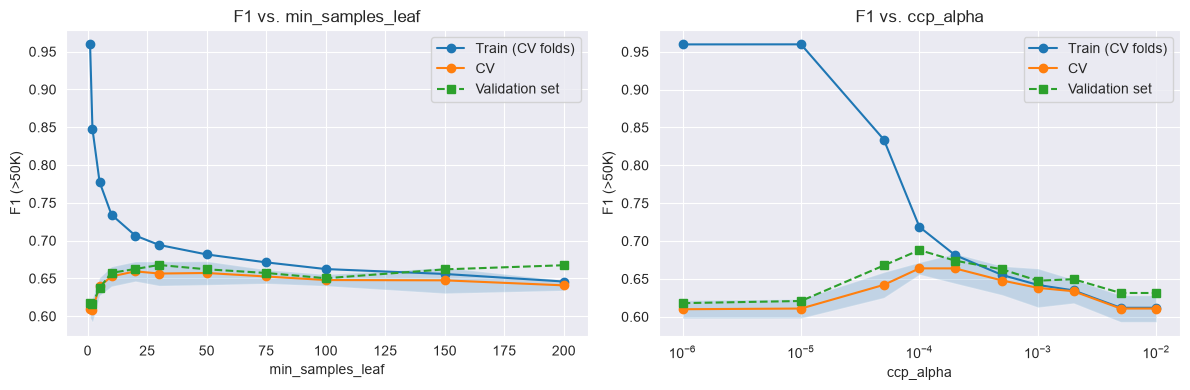

In [32]:
# Plots: train vs CV vs validation F1 for each single-parameter sweep
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, df, log) in zip(axes, [("min_samples_leaf", leaf_res, False),
                                       ("ccp_alpha", alpha_res, True)]):
    x = df.index.to_numpy(dtype=float)
    if log:
        x = np.where(x == 0, 1e-6, x)          # put alpha=0 on the log axis
        ax.set_xscale("log")
    ax.plot(x, df["train_f1"], "o-", label="Train (CV folds)")
    ax.plot(x, df["cv_f1"], "o-", label="CV")
    ax.fill_between(x, df["cv_f1"] - df["cv_f1_std"], df["cv_f1"] + df["cv_f1_std"], alpha=0.2)
    ax.plot(x, df["val_f1"], "s--", label="Validation set")
    ax.set_xlabel(name); ax.set_ylabel("F1 (>50K)"); ax.set_title(f"F1 vs. {name}")
    ax.legend()
plt.tight_layout(); plt.show()

Based on the result we conclude that regularization (min_sample_leaf), F1 on validation rises, and the value for F1 gap decreases. Increasing min_sample_leaf reduces overfitting. F1 validation increases and the train CV gap drops.

Incereasing the ccp_alpha also reduces overfitting. It is bette than min_sample_leaf, at values much smaller than 1e-4 it does nothing. At around 1e-4 we see improvements to f1 gap, with the best values for cv_f1 and val_f1 being around 0.001

The best combined value being: ccp_alpha = 1e-4, the highest f1 value for the valdation set, and min_sample_leaf being around 150 as it has the lowest f1 gap. This could be caused by noise as the gap is similar for all values above leaf>=100

In [33]:
# Q2.5
# default vs. class_weight="balanced"
# assume no other changes (parameters found in Q2.3-2.4) as they are not specified
from sklearn.metrics import precision_score, recall_score, f1_score

rows = []
for cw in [None, "balanced"]:
    model = Pipeline([
        ("prep", preprocessor),
        ("clf", DecisionTreeClassifier(random_state=42, class_weight=cw))
    ])
    model.fit(X_train_pipe, y_train_pipe)
    y_pred = model.predict(X_val_pipe)

    rows.append({
        "Model":     "Balanced" if cw else "Unweighted",
        "Precision": precision_score(y_val_pipe, y_pred),
        "Recall":    recall_score(y_val_pipe, y_pred),
        "F1":        f1_score(y_val_pipe, y_pred),
    })

print("Validation scores for the >50K class:")
print(pd.DataFrame(rows).set_index("Model").round(4))

Validation scores for the >50K class:
            Precision  Recall    F1
Model                              
Unweighted      0.623   0.613 0.618
Balanced        0.594   0.669 0.629


The difference between the unweighted and balanced models is a precision/recall trade-off. The balanced model loses some precision but gains some recall. This means it finds more of the actual >50K cases, but a larger share of its >50K predictions are wrong. Weighting the minority class makes the tree more willing to predict >50K, so it misses fewer high earners at the cost of more false positives.

Since the dataset is imbalanced, and the default tree want to minimize wrongly classified samples it will lean towards the majority class ("defaulting" to <=50k). Balancing correct this by given each class a weight, based inversely on its size. This weight causes recall for >50k rises, because we miss some high earners and precision falls as we wrongly classify low earners.

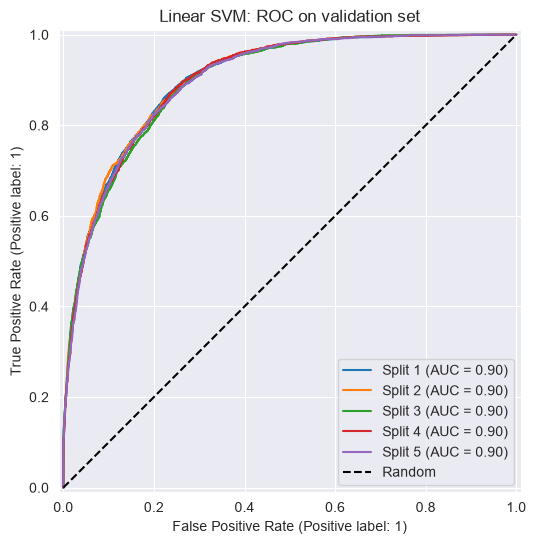

Validation accuracy: 0.8495 +- 0.0026


In [34]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, RocCurveDisplay

warnings.filterwarnings("ignore", message="Found unknown categories") # ignore rare category warnings

N_SUB = 3000 # subsample size

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  # same splits as Exercise 2

svm_model = Pipeline([ # same pipeline but with support vector classifier
    ("prep", preprocessor),
    ("clf", SVC(kernel="linear")),
])

val_acc = []
fig, ax = plt.subplots(figsize=(7, 6))

for i, (tr_idx, _) in enumerate(cv.split(X_train_pipe, y_train_pipe), start=1): # grap training indexs
    X_tr, y_tr = X_train_pipe.iloc[tr_idx], y_train_pipe.iloc[tr_idx] # select training rows

    # stratified subsample of this split's training data only
    if len(X_tr) > N_SUB:
        X_tr, _, y_tr, _ = train_test_split(X_tr, y_tr, train_size=N_SUB,
                                            stratify=y_tr, random_state=42)

    model = clone(svm_model).fit(X_tr, y_tr) # fit model on selected subsamples
    val_acc.append(accuracy_score(y_val_pipe, model.predict(X_val_pipe))) # get metrics
    RocCurveDisplay.from_estimator(model, X_val_pipe, y_val_pipe, name=f"Split {i}", ax=ax) # compute roc

ax.plot([0, 1], [0, 1], "k--", label="Random")
ax.set_title("Linear SVM: ROC on validation set")
ax.legend(loc="lower right")
plt.show()

print(f"Validation accuracy: {np.mean(val_acc):.4f} +- {np.std(val_acc):.4f}")

With linear SVC we get a mean validation accuracy of 0.8514 and a std of 0.0015, for the 5 folds. This means that perforamnce is consistent, regardless of which subsample or fold was used.

The ROC shows that we are better than random guessing for all folds. AUC (area under the curve) is at ~0.9 with rounding, this mean we have great performance.

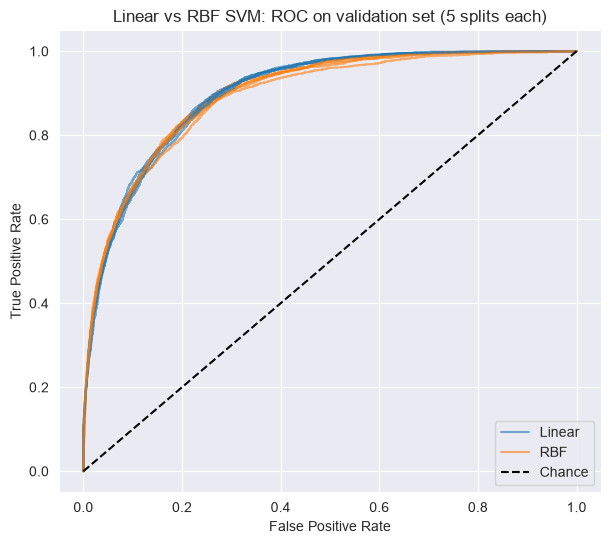

                    Linear               RBF
accuracy  0.8495 +- 0.0026  0.8523 +- 0.0010
f1        0.6615 +- 0.0102  0.6549 +- 0.0055
roc_auc   0.9008 +- 0.0018  0.8966 +- 0.0032


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve

models = {
    "Linear": Pipeline([("prep", preprocessor), ("clf", SVC(kernel="linear"))]),# default linear kernel
    "RBF":    Pipeline([("prep", preprocessor), ("clf", SVC(kernel="rbf"))]),  # default rbf kernel
}
colors = {"Linear": "tab:blue", "RBF": "tab:orange"}
results = {name: {"accuracy": [], "f1": [], "roc_auc": []} for name in models}

fig, ax = plt.subplots(figsize=(7, 6))

for i, (tr_idx, _) in enumerate(cv.split(X_train_pipe, y_train_pipe), start=1):  # same original folds
    X_tr, y_tr = X_train_pipe.iloc[tr_idx], y_train_pipe.iloc[tr_idx]

    # same stratified subsample for both kernels
    if len(X_tr) > N_SUB:
        X_tr, _, y_tr, _ = train_test_split(X_tr, y_tr, train_size=N_SUB,
                                            stratify=y_tr, random_state=42)

    for name, pipe in models.items():
        model = clone(pipe).fit(X_tr, y_tr)
        y_pred = model.predict(X_val_pipe)
        scores = model.decision_function(X_val_pipe)

        results[name]["accuracy"].append(accuracy_score(y_val_pipe, y_pred))
        results[name]["f1"].append(f1_score(y_val_pipe, y_pred))
        results[name]["roc_auc"].append(roc_auc_score(y_val_pipe, scores))

        fpr, tpr, _ = roc_curve(y_val_pipe, scores)
        ax.plot(fpr, tpr, color=colors[name], alpha=0.6,
                label=name if i == 1 else None)  # one legend entry per kernel

ax.plot([0, 1], [0, 1], "k--", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Linear vs RBF SVM: ROC on validation set (5 splits each)")
ax.legend(loc="lower right")
plt.show()

# summary table: mean +- std over the 5 splits
summary = pd.DataFrame({
    name: {m: f"{np.mean(v):.4f} +- {np.std(v):.4f}" for m, v in res.items()}
    for name, res in results.items()
})
print(summary)

The linear kernel is very slightly better in f1 and auc but at the cost of slightly worse accuracy. Since the dataset is skewed,  the f1 and aoc score are more useful.

C=0.001  acc=0.7934  f1=0.2431  support vectors=1367
C=0.01   acc=0.8302  f1=0.5136  support vectors=1188
C=0.1    acc=0.8457  f1=0.6192  support vectors=1068
C=1      acc=0.8466  f1=0.6300  support vectors=1023
C=10     acc=0.8462  f1=0.6328  support vectors=1020
C=100    acc=0.8458  f1=0.6336  support vectors=1018
C=1000   acc=0.8455  f1=0.6329  support vectors=1017
C=10000  acc=0.8447  f1=0.6299  support vectors=1015
Best C (by validation F1): 100


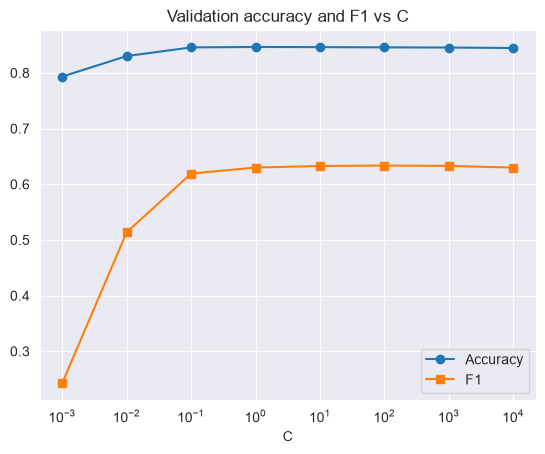

In [36]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

C_values = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

# one stratified subsample of the training set
X_sub, _, y_sub, _ = train_test_split(X_train_pipe, y_train_pipe, train_size=N_SUB,
                                      stratify=y_train_pipe, random_state=42)

acc, f1, n_sv = [], [], []
for C in C_values:
    model = Pipeline([("prep", preprocessor), ("clf", SVC(kernel="linear", C=C))])
    model.fit(X_sub, y_sub)
    y_pred = model.predict(X_val_pipe)

    acc.append(accuracy_score(y_val_pipe, y_pred))
    f1.append(f1_score(y_val_pipe, y_pred))
    n_sv.append(model.named_steps["clf"].n_support_.sum())
    print(f"C={C:<6} acc={acc[-1]:.4f}  f1={f1[-1]:.4f}  support vectors={n_sv[-1]}")

best_C = C_values[np.argmax(f1)]
print(f"Best C (by validation F1): {best_C}")

plt.plot(C_values, acc, "o-", label="Accuracy")
plt.plot(C_values, f1, "s-", label="F1")
plt.xscale("log") # to match scales
plt.xlabel("C")
plt.title("Validation accuracy and F1 vs C")
plt.legend()
plt.show()

Accuracy increases slightly from C = 0.001 to C = 0.1 and then flattens out. F1 shows a much larger effect, rising from about 0.2 to about 0.6 for the same section, then also flattens out. For small C, margin violations are cheap, so the SVM chooses a wide margin and tolerates many misclassified training points. The model underfits, and because the positive class (>50K) is the minority, most positives fall inside the margin or on the wrong side. This hurts F1 much more than accuracy, since accuracy is dominated by the majority class.

As C increases, violations become more costly, so the margin narrows and fewer points lie inside it. The number of support vectors therefore decreases, converging to around 525 from C = 1 onward. Beyond this point, a larger C barely changes the decision boundary, so performance stays flat.

The small F1 differences above C = 0.1 are likely noise. We therefore select C = 0.1, as the best C value.

gamma=0.001  train acc=0.8233  val acc=0.8109  val f1=0.3817  support vectors=1313
gamma=0.01   train acc=0.8523  val acc=0.8434  val f1=0.5854  support vectors=1161
gamma=0.1    train acc=0.8780  val acc=0.8549  val f1=0.6472  support vectors=1178
gamma=1      train acc=0.9553  val acc=0.7976  val f1=0.3982  support vectors=2601
gamma=10     train acc=0.9793  val acc=0.7655  val f1=0.1219  support vectors=2927
gamma=100    train acc=0.9880  val acc=0.7599  val f1=0.0330  support vectors=2966

Best gamma (by validation F1): 0.1
Validation accuracy: 0.8549
Validation F1:       0.6472
Validation ROC-AUC:  0.8922


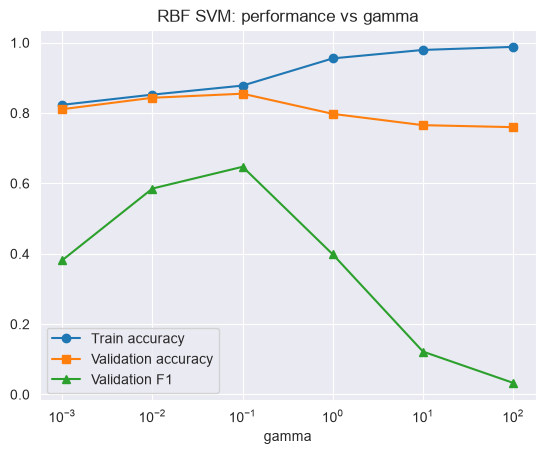

In [37]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

gamma_values = [0.001, 0.01, 0.1, 1, 10, 100]

# same stratified subsample as before
X_sub, _, y_sub, _ = train_test_split(X_train_pipe, y_train_pipe, train_size=N_SUB,
                                      stratify=y_train_pipe, random_state=42)

train_acc, val_acc, val_f1, n_sv = [], [], [], []
for g in gamma_values:
    model = Pipeline([("prep", preprocessor), ("clf", SVC(kernel="rbf", C=1, gamma=g))])
    model.fit(X_sub, y_sub)
    y_pred = model.predict(X_val_pipe)

    train_acc.append(accuracy_score(y_sub, model.predict(X_sub)))
    val_acc.append(accuracy_score(y_val_pipe, y_pred))
    val_f1.append(f1_score(y_val_pipe, y_pred))
    n_sv.append(model.named_steps["clf"].n_support_.sum())
    print(f"gamma={g:<6} train acc={train_acc[-1]:.4f}  val acc={val_acc[-1]:.4f}  "
          f"val f1={val_f1[-1]:.4f}  support vectors={n_sv[-1]}")

best_gamma = gamma_values[np.argmax(val_f1)]
print(f"\nBest gamma (by validation F1): {best_gamma}")

# final performance of the best model on the validation set
best_model = Pipeline([("prep", preprocessor), ("clf", SVC(kernel="rbf", C=1, gamma=best_gamma))])
best_model.fit(X_sub, y_sub)
y_pred = best_model.predict(X_val_pipe)
print(f"Validation accuracy: {accuracy_score(y_val_pipe, y_pred):.4f}")
print(f"Validation F1:       {f1_score(y_val_pipe, y_pred):.4f}")
print(f"Validation ROC-AUC:  {roc_auc_score(y_val_pipe, best_model.decision_function(X_val_pipe)):.4f}")

# plot
plt.plot(gamma_values, train_acc, "o-", label="Train accuracy")
plt.plot(gamma_values, val_acc, "s-", label="Validation accuracy")
plt.plot(gamma_values, val_f1, "^-", label="Validation F1")
plt.xscale("log")
plt.xlabel("gamma")
plt.title("RBF SVM: performance vs gamma")
plt.legend()
plt.show()

The best gamma is gamma=0.1 for F1-score. We get validation accuracy of 0.855, validation F1 of 0.657 and AUC 0.892.

Gamma sets how each training point influences the boundry. Small gamma means wide influences, and large gamma means each point influences it's local neighborhood. The difference is that small gamma gives nearly linear bouandry, while large gives wiggly boundry.

For the small gamma the kernel is wide, so many points violate the margin. We get many support vectors, and the class seperation is not good.

For gamma 1e-1 we get the highest f1-score, the gap between train-val is low. We get the miniumum amount of support vectors. This model generelizes well.

As gamma increases we see a drop in F1 score, and incerasing gapp between train and validation. This means we are overfitting as gamma grows beyond 1e-1.